In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z)) 
        
def relu(Z):
    return np.maximum(0, Z)

def tanh(Z):
    return np.tanh(Z)
    
def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z), axis = 0, keepdims = True)
    

In [3]:
class Neural_network():
    '''
    Class for a neural network.
    '''
    
    def __init__(self, layer_sizes, layer_activations, learning_rate, epochs, dropout = 1, beta1 = 0.9, beta2 = 0.999, 
                 epsilon = 1e-8):
        '''
        initialize the neural network.
        '''
        self.layer_sizes = layer_sizes
        self.layer_activations = layer_activations
        self.learning_rate = learning_rate
        self.dropout = dropout
        self.epochs = epochs
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        
        # Initialize parameters of each layer
        self.params = {}
        for i in range(1, len(layer_sizes)):
            self.params['W' + str(i)] = np.random.randn(layer_sizes[i], layer_sizes[i - 1]) * 0.01
            self.params['b' + str(i)] = np.zeros((layer_sizes[i], 1))
            
        # Initialize velocity and stuff for Adam
        self.v = {}
        self.s = {}
        
        for i in range(1, len(layer_sizes)):

            self.v["dW" + str(i)] = np.zeros(self.params["W" + str(i)].shape)
            self.v["db" + str(i)] = np.zeros(self.params["b" + str(i)].shape)
            self.s["dW" + str(i)] = np.zeros(self.params["W" + str(i)].shape)
            self.s["db" + str(i)] = np.zeros(self.params["b" + str(i)].shape)
            
            
    def forward_prop(self, X):
        '''
        Performs forward propagation for an iteration.
        '''
        
        A_prev = X
        Z = [0]
        A = [A_prev]
        
        for i in range(len(self.layer_activations)):
            
            Zi = np.dot(self.params['W' + str(i + 1)], A_prev) + self.params['b' + str(i + 1)]
            if self.layer_activations[i] == 'sigmoid':
                A_prev = sigmoid(Zi)
            elif self.layer_activations[i] == 'relu':
                A_prev = relu(Zi)
            elif self.layer_activations[i] == 'tanh':
                A_prev = tanh(Zi)
            elif self.layer_activations[i] == 'linear':
                A_prev = Zi
            elif self.layer_activations[i] == 'softmax':
                A_prev = softmax(Zi)
            
            A.append(A_prev)
            Z.append(Zi)

        return A, Z
    
    
    def compute_cost(self, Y, Y_hat):
        '''
        Computes the cost of an iteration
        '''
        
        m = Y.shape[1]
        
        if self.layer_activations[-1] == 'sigmoid':
            cost = - np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat)) / m 
        elif self.layer_activations[-1] == 'linear':
            cost = np.sum((Y_hat - Y) ** 2) / (2 * m)
        elif self.layer_activations[-1] == 'softmax':
            cost = - np.sum(Y * np.log(Y_hat)) / m
        
        return np.squeeze(cost)
    
    
    def back_prop(self, X, Y, A, Z):
        m = X.shape[1]
        grads = {}
        L = len(self.layer_sizes) - 1
        Y = Y.reshape(A[-1].shape)
        
        if self.layer_activations[-1] == 'sigmoid':
            dAL = - (np.divide(Y, A[-1]) - np.divide(1 - Y, 1 - A[-1]))
            dZL = A[-1] * (1 - A[-1]) * dAL
        elif self.layer_activations[-1] == 'linear':
            dAL = A[-1] - Y
            dZL = dAL
        elif self.layer_activations[-1] == 'softmax':
            dAL = - Y / A[-1]
            
        A_prev = A[-2]
        
        grads['dW' + str(L)] = np.dot(dZL, A_prev.T) / m
        grads['db' + str(L)] = np.sum(dZL, axis = 1, keepdims = True) / m
        dA_prev = np.dot(self.params['W' + str(L)].T, dZL)
        
        for i in reversed(range(L - 1)):
            
            A_prev = A[i]
            Zi = Z[i]
            if self.layer_activations[i] == 'sigmoid':
                dZl = A_prev * (1 - A_prev) * dA_prev
            elif self.layer_activations[i] == 'relu': 
                dZl = (Zi > 0) * dA_prev 
            elif self.layer_activations[i] == 'tanh':
                dZl = (1 - A_prev ** 2) * dA_prev
                
            grads['dW' + str(i + 1)] = np.dot(dZl, A_prev.T) / m
            grads['db' + str(i + 1)] = np.sum(dZl, axis=1, keepdims=True) / m
            dA_prev = np.dot(self.params['W' + str(i + 1)].T, dZl)
            
        return grads
    

    def fit(self, X_train, Y_train):
        costs = []
        for epoch in range(self.epochs):
            A, Z = self.forward_prop(X_train)
            cost = self.compute_cost(Y_train, A[-1])
            grads = self.back_prop(X_train, Y_train, A, Z)
            self.update_params(grads, epoch + 1)
            costs.append(cost)
            if epoch % 1000 == 0:
                print(f"Cost at epoch {epoch} is {cost}")
        plt.plot(costs)
        plt.xlabel("epochs")
        plt.ylabel("cost")
        

    
    def update_params(self, grads, t):
        # Correction for moving averages
        self.v_corrected = {}            
        self.s_corrected = {} 
        for i in range(1, len(self.layer_sizes)):
            self.v["dW" + str(i)] = self.beta1 * self.v["dW" + str(i)] + (1 - self.beta1) * grads["dW" + str(i)]
            self.v["db" + str(i)] = self.beta1 * self.v["db" + str(i)] + (1 - self.beta1) * grads["db" + str(i)]   
            
            # Bias correction
            self.v_corrected["dW" + str(i)] = self.v["dW" + str(i)] / (1 - self.beta1 ** t)
            self.v_corrected["db" + str(i)] = self.v["db" + str(i)] / (1 - self.beta1 ** t)
            
            # Almost same stuff as v, just with square
            self.s["dW" + str(i)] = self.beta2 * self.s["dW" + str(i)] + (1 - self.beta2) * (grads["dW" + str(i)] ** 2)
            self.s["db" + str(i)] = self.beta2 * self.s["db" + str(i)] + (1 - self.beta2) * (grads["db" + str(i)] ** 2) 
            
            self.s_corrected["dW" + str(i)] = self.s["dW" + str(i)] / (1 - self.beta2 ** t)
            self.s_corrected["db" + str(i)] = self.s["db" + str(i)] / (1 - self.beta2 ** t)
            
            self.params['W' + str(i)] -= self.learning_rate * (self.v_corrected['dW' + str(i)] / np.sqrt(self.s_corrected['dW' + str(i)] + self.epsilon))
            self.params['b' + str(i)] -= self.learning_rate * (self.v_corrected['db' + str(i)] / np.sqrt(self.s_corrected['db' + str(i)] + self.epsilon))
            
            
    def predict(self, X):
        A, Z = self.forward_prop(X)
        return A[-1]

Cost at epoch 0 is 20.33395162530945
Cost at epoch 1000 is 0.8261910632086774
Cost at epoch 2000 is 0.3257791035515034
Cost at epoch 3000 is 0.08548812466704474
Cost at epoch 4000 is 0.01123338007946425
Cost at epoch 5000 is 0.0004267522868075343
Cost at epoch 6000 is 1.8878084051756014e-06
Cost at epoch 7000 is 2.2804057252854837e-10
Cost at epoch 8000 is 7.355967616994088e-17
Cost at epoch 9000 is 2.092867703073975e-27
Predicted Y for X_test: [[5.99999994]]


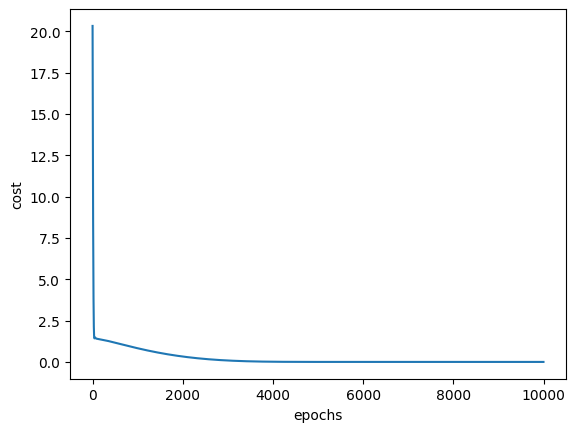

In [4]:
# Generate synthetic data
X_train = np.random.rand(1, 100)
Y_train = 6 * X_train + 3

# Create and train the neural network
model = Neural_network(layer_sizes=[1, 3, 1], layer_activations=['relu', 'linear'], learning_rate=0.2, epochs=10000)
costs = model.fit(X_train, Y_train)

# Test the model
X_test = np.array([[0.5]])
predicted_y = model.predict(X_test)
print(f"Predicted Y for X_test: {predicted_y}")